In [1]:
import math

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
CLIP_VAL = 7.192

df = pd.read_csv("results/preds_hybrid_conf_2026-09-03T09_42_52_rep1.csv")  # w_anchor=1

# With IPW
df_ipw = pd.read_csv("results/preds_hybrid_conf_2026-09-04T22_29_24_rep1.csv")  # w = 1
# df_ipw = pd.read_csv("results/preds_hybrid_conf_2026-09-05T10_41_43_rep1.csv")  # w = 0.97
print(df.shape)

(148, 10)


In [3]:
df.describe()

,mu0,mu1,y0_mean,y1_mean,y0_std,y1_std,y0_lo95,y0_hi95,y1_lo95,y1_hi95
count,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000
mean,-0.456661,1.093815,0.226367,1.033112,5.541482,0.455175,-7.170217,7.175516,0.208233,1.929452
std,0.628009,0.182739,0.812932,0.097316,0.270192,0.070849,0.044101,0.032243,0.231362,0.248859
min,-1.147673,0.763769,-1.949632,0.802168,4.495597,0.307774,-7.191954,6.936440,-0.646896,1.398062
25%,-0.870080,0.956562,-0.357699,0.962894,5.403522,0.407651,-7.191954,7.173650,0.053594,1.757138
50%,-0.617763,1.076854,0.261217,1.037944,5.572591,0.458084,-7.187808,7.188524,0.261325,1.913613
75%,-0.231622,1.211606,0.839391,1.101513,5.724322,0.498749,-7.174828,7.191796,0.376334,2.079145
max,2.715451,1.680429,2.396279,1.300159,6.105121,0.710314,-6.887979,7.191954,0.600253,2.713931


In [4]:
df_ipw.describe()

,mu0,mu1,y0_mean,y1_mean,y0_std,y1_std,y0_lo95,y0_hi95,y1_lo95,y1_hi95
count,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000
mean,-0.456661,1.093815,-0.880252,1.199647,1.839405,1.012497,-5.654981,1.783845,-0.550677,3.251686
std,0.628009,0.182739,0.391697,0.170948,0.303591,0.265903,1.014175,1.125855,0.966084,0.758517
min,-1.147673,0.763769,-1.858234,0.743879,0.909010,0.422355,-7.122738,0.089444,-4.197423,1.758405
25%,-0.870080,0.956562,-1.183293,1.085254,1.642117,0.810235,-6.562505,0.896193,-0.927303,2.681484
50%,-0.617763,1.076854,-0.874252,1.197340,1.851251,1.001224,-5.735230,1.555690,-0.192326,3.065755
75%,-0.231622,1.211606,-0.571436,1.322843,2.044616,1.161644,-5.057069,2.420390,0.140489,3.687810
max,2.715451,1.680429,-0.016592,1.606484,2.580761,1.890772,-2.461512,5.948631,0.648044,5.565989


In [5]:
print("No IPW")
print("  Rows w/ y0_lo95 == its minimum:", sum(df["y0_lo95"] == df["y0_lo95"].min()))
print("  Rows w/ y0_hi95 == its maximum:", sum(df["y0_hi95"] == df["y0_hi95"].max()))
print("  Rows w/ y1_lo95 == its minimum:", sum(df["y1_lo95"] == df["y1_lo95"].min()))
print("  Rows w/ y1_hi95 == its maximum:", sum(df["y1_hi95"] == df["y1_hi95"].max()))

print("\nWith IPW")
print("  Rows w/ y0_lo95 == its minimum:", sum(df_ipw["y0_lo95"] == df_ipw["y0_lo95"].min()))
print("  Rows w/ y0_hi95 == its maximum:", sum(df_ipw["y0_hi95"] == df_ipw["y0_hi95"].max()))
print("  Rows w/ y1_lo95 == its minimum:", sum(df_ipw["y1_lo95"] == df_ipw["y1_lo95"].min()))
print("  Rows w/ y1_hi95 == its maximum:", sum(df_ipw["y1_hi95"] == df_ipw["y1_hi95"].max()))

No IPW
  Rows w/ y0_lo95 == its minimum: 40
  Rows w/ y0_hi95 == its maximum: 35
  Rows w/ y1_lo95 == its minimum: 1
  Rows w/ y1_hi95 == its maximum: 1

With IPW
  Rows w/ y0_lo95 == its minimum: 1
  Rows w/ y0_hi95 == its maximum: 1
  Rows w/ y1_lo95 == its minimum: 1
  Rows w/ y1_hi95 == its maximum: 1


Number of bins: 13


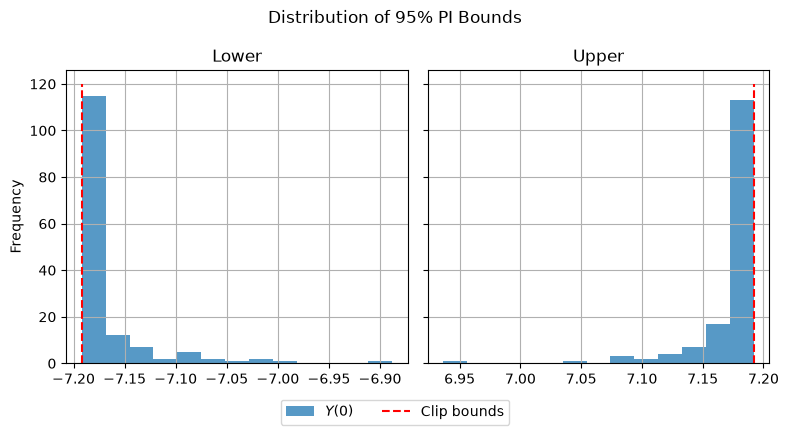

In [6]:
num_bins = math.ceil(math.sqrt(len(df)))
print(f"Number of bins: {num_bins}")

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
density = False
ymax = 120

fig.sca(ax0)
df["y0_lo95"].hist(bins=round(num_bins), density=density, label=r"$Y(0)$", alpha=0.75)
# df["y1_lo95"].hist(bins=round(num_bins), density=density, label=r"$Y(1)$", alpha=0.75)
plt.vlines(-CLIP_VAL, 0, ymax, colors="red", linestyles="dashed", label="Clip lower bound")
ax0.set_ylabel("Frequency Density" if density else "Frequency")
ax0.set_title("Lower")

fig.sca(ax1)
df["y0_hi95"].hist(bins=round(num_bins), density=density, label=r"$Y(0)$", alpha=0.75)
# df["y1_hi95"].hist(bins=round(num_bins), density=density, label=r"$Y(1)$", alpha=0.75)
xmin, xmax = ax1.get_xlim()
plt.vlines(CLIP_VAL, 0, ymax, colors="red", linestyles="dashed", label="Clip upper bound")
ax1.set_title("Upper")

fig.suptitle("Distribution of 95% PI Bounds")
fig.legend(
    [r"$Y(0)$", "Clip bounds"], loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.075)
)
plt.tight_layout()
plt.show()

Number of bins: 13


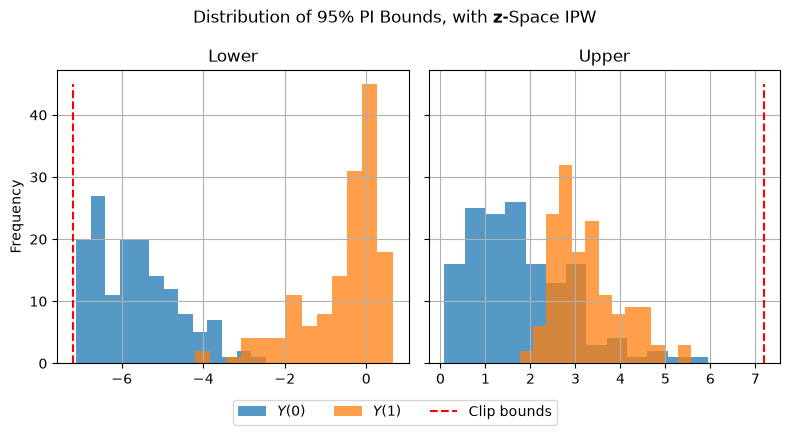

In [7]:
num_bins = math.ceil(math.sqrt(len(df)))
print(f"Number of bins: {num_bins}")

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
density = False
ymax = 45

fig.sca(ax0)
df_ipw["y0_lo95"].hist(bins=round(num_bins), density=density, label=r"$Y(0)$", alpha=0.75)
df_ipw["y1_lo95"].hist(bins=round(num_bins), density=density, label=r"$Y(1)$", alpha=0.75)
plt.vlines(-CLIP_VAL, 0, ymax, colors="red", linestyles="dashed", label="Clip lower bound")
ax0.set_ylabel("Frequency Density" if density else "Frequency")
ax0.set_title("Lower")

fig.sca(ax1)
df_ipw["y0_hi95"].hist(bins=round(num_bins), density=density, label=r"$Y(0)$", alpha=0.75)
df_ipw["y1_hi95"].hist(bins=round(num_bins), density=density, label=r"$Y(1)$", alpha=0.75)
xmin, xmax = ax1.get_xlim()
plt.vlines(CLIP_VAL, 0, ymax, colors="red", linestyles="dashed", label="Clip upper bound")
ax1.set_title("Upper")

fig.suptitle(r"Distribution of 95% PI Bounds, with $\mathbf{z}$-Space IPW")
fig.legend(
    [r"$Y(0)$", r"$Y(1)$", "Clip bounds"],
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.075),
)
plt.tight_layout()
plt.show()

In [8]:
df.nsmallest(10, "y0_lo95")["y0_lo95"]

5    -7.191954
12   -7.191954
13   -7.191954
25   -7.191954
26   -7.191954
27   -7.191954
38   -7.191954
39   -7.191954
42   -7.191954
44   -7.191954
Name: y0_lo95, dtype: float64

In [9]:
df.nlargest(10, "y0_hi95")["y0_hi95"]

0     7.191954
1     7.191954
16    7.191954
20    7.191954
23    7.191954
38    7.191954
40    7.191954
46    7.191954
50    7.191954
55    7.191954
Name: y0_hi95, dtype: float64